# 📊 Análise Exploratória Detalhada e Previsão de Crimes Violentos - MG (2012 - 2025)

Este notebook realiza:
- Visualizações detalhadas para avaliação dos dados.
- Modelagem e previsão para o ano de 2025.

Utilizamos os dados unificados de crimes e o banco complementar de municípios do IBGE para enriquecer as análises.


> ⚠️ **Aviso:** Os dados analisados representam registros oficiais de crimes violentos e podem envolver informações sensíveis. Todas as análises têm caráter estatístico e não devem ser interpretadas fora do contexto de políticas públicas, fatores socioeconômicos e variações regionais. Este trabalho tem fins exclusivamente educacionais e informativos.


## 📚 Scripts 
- [src/conversao_banco_sql.py](../src/conversao_banco_sql.py): Criação e importação do banco de crimes.
- [src/conversao_ibge_sql.py](../src/conversao_ibge_sql.py): Criação e importação do banco de municípios IBGE.
- [src/sql_normalizacao_codmunicipio.py](../src/sql_normalizacao_codmunicipio.py): Normalização dos códigos e nomes de municípios entre os bancos.
- [src/limpeza.py](../src/limpeza.py): Funções de limpeza e padronização dos dados.

> ⚠️ Os dados do IBGE foram tratados manualmente em Excel antes da importação, resultando no arquivo docs/Municipios_pre_tratados.csv. Este arquivo foi utilizado como base para gerar o banco municipios_ibge.sqlite.

 Os dados foram tratados e armazenados nos bancos SQLite:
- data/database/crimes_mg.sqlite
- data/database/municipios_ibge.sqlite

## 🔎 1. Importar bibliotecas e conectar aos bancos de dados

In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

sns.set(style="whitegrid")

# Conexão aos bancos
conn_crimes = sqlite3.connect('../data/database/crimes_mg.sqlite')
conn_ibge = sqlite3.connect('../data/database/municipios_ibge.sqlite')

print("[INFO] Conexões estabelecidas com os bancos de dados.")

[INFO] Conexões estabelecidas com os bancos de dados.


## 📈 2. Análise Exploratória Detalhada (EDA) - (2012 - 2024)

Nesta seção, exploramos os dados históricos de crimes violentos registrados em Minas Gerais entre os anos de 2012 e 2024, com o objetivo de identificar padrões, tendências e distribuições relevantes.

### 2.1. Distribuição total de crimes por ano

In [2]:
query_ano = '''
SELECT ano, SUM(registros) AS total_registros
FROM crimes
GROUP BY ano
ORDER BY ano
'''
df_ano = pd.read_sql_query(query_ano, conn_crimes)

fig = px.line(df_ano, x='ano', y='total_registros', markers=True,
              title='Distribuição total de crimes por ano em MG (2012-2024)',
              labels={'ano': 'Ano', 'total_registros': 'Total de Registros'},
              hover_data={'ano': True, 'total_registros': True})

# Anotações dos valores
for i, row in df_ano.iterrows():
    fig.add_annotation(x=row['ano'], y=row['total_registros'],
                       text=f"{int(row['total_registros']):,}",
                       showarrow=True,
                       arrowhead=1,
                       ax=0,
                       ay=-15,
                       font=dict(size=10, color="black"))

fig.show()

### 2.2 Ranking dos municípios com maior número total de crimes:

In [4]:
query_top10 = '''
SELECT municipio, SUM(registros) AS total_registros
FROM crimes
GROUP BY municipio
ORDER BY total_registros DESC
LIMIT 10
'''
df_top10 = pd.read_sql_query(query_top10, conn_crimes)

fig = px.bar(
    df_top10,
    x='municipio',
    y='total_registros',
    title='Ranking dos municípios com maior número total de crimes (2012-2024)',
    labels={'municipio': 'Município', 'total_registros': 'Total de Registros'},
    hover_data={'municipio': True, 'total_registros': True},
    text=df_top10['total_registros'].apply(lambda x: f'{int(x):,}')
)

fig.update_traces(
    textposition='outside',
    textfont=dict(size=10)
)

fig.update_layout(
    xaxis_tickangle=-45,
    height=600,
    margin=dict(t=100, r=100),
    uniformtext_minsize=8,
    uniformtext_mode='hide'
)

fig.show()

### 2.3. Ranking das naturezas de crime com maior número de ocorrências:

In [5]:
query_natureza = '''
SELECT natureza, SUM(registros) AS total_registros
FROM crimes
GROUP BY natureza
ORDER BY total_registros DESC
LIMIT 10
'''

df_natureza = pd.read_sql_query(query_natureza, conn_crimes)
fig = px.pie(
    df_natureza,
    values='total_registros',
    names='natureza',
    title='Distribuição dos crimes por natureza (Donut)',
    hole=0.5,  # define o centro oco
    hover_data=['natureza', 'total_registros'],
    color_discrete_sequence=px.colors.qualitative.Set2
)

fig.update_traces(
    textinfo='label+percent',
    textfont_size=11,
    marker=dict(line=dict(color='white', width=2))
)

fig.update_layout(
    height=600,
    margin=dict(t=80, b=50, l=50, r=50)
)

fig.show()

### 2.4. Análise temporal mensal para os ranking 5 municípios com mais registros:

In [6]:
query_mensal = '''
SELECT municipio, ano, mes, SUM(registros) AS total_registros
FROM crimes
GROUP BY municipio, ano, mes
ORDER BY municipio, ano, mes
'''

df_mensal = pd.read_sql_query(query_mensal, conn_crimes)

# Selecionar os top 5 municípios por soma total de registros
top5_mun = df_mensal.groupby('municipio')['total_registros'].sum().nlargest(5).index.tolist()
df_mensal_top5 = df_mensal[df_mensal['municipio'].isin(top5_mun)].copy()

# Criar coluna 'data' para linha temporal
df_mensal_top5['data'] = pd.to_datetime(df_mensal_top5['ano'].astype(str) + '-' + df_mensal_top5['mes'].astype(str).str.zfill(2) + '-01')

# Ordenar para visualização consistente
df_mensal_top5 = df_mensal_top5.sort_values(['municipio', 'data'])

# Plot
import plotly.express as px

fig = px.line(
    df_mensal_top5,
    x='data',
    y='total_registros',
    color='municipio',
    markers=True,
    title='📈 Análise Temporal Mensal dos Top 5 Municípios (2012–2024)',
    labels={'data': 'Data', 'total_registros': 'Total de Registros', 'municipio': 'Município'},
    hover_data={'municipio': True, 'data': True, 'total_registros': True}
)

fig.update_layout(
    hovermode='x unified',
    xaxis=dict(rangeslider_visible=True),
    legend_title_text='Município'
)

fig.show()

# 🔄 3. Backtesting (Validação dos Modelos)

Nesta etapa, avaliamos a capacidade preditiva de três abordagens distintas aplicadas à série temporal do total anual de crimes em MG. A validação é feita por meio de **backtesting**, onde utilizamos dados históricos para prever anos recentes (2023 e 2024) e comparamos os resultados com os valores reais.

Os modelos avaliados são:
- 🔹 Regressão Linear Simples
- 🔹 Séries Temporais com ARIMA (AutoRegressive Integrated Moving Average)
- 🔹 Regressão baseada em Árvores (Random Forest)

As métricas utilizadas para avaliação do desempenho dos modelos são:
- **MAE (Erro Absoluto Médio)**: média dos erros absolutos.
- **RMSE (Raiz do Erro Quadrático Médio)**: penaliza erros grandes e mede a precisão.

Esses indicadores nos ajudam a entender qual modelo possui melhor capacidade de generalização e menor erro de previsão.

Resultados do Backtesting (2023-2024):
Regressão Linear: MAE = 7070.22, RMSE = 8291.26
ARIMA: MAE = 3677.09, RMSE = 3688.69
Random Forest: MAE = 6181.51, RMSE = 6185.48


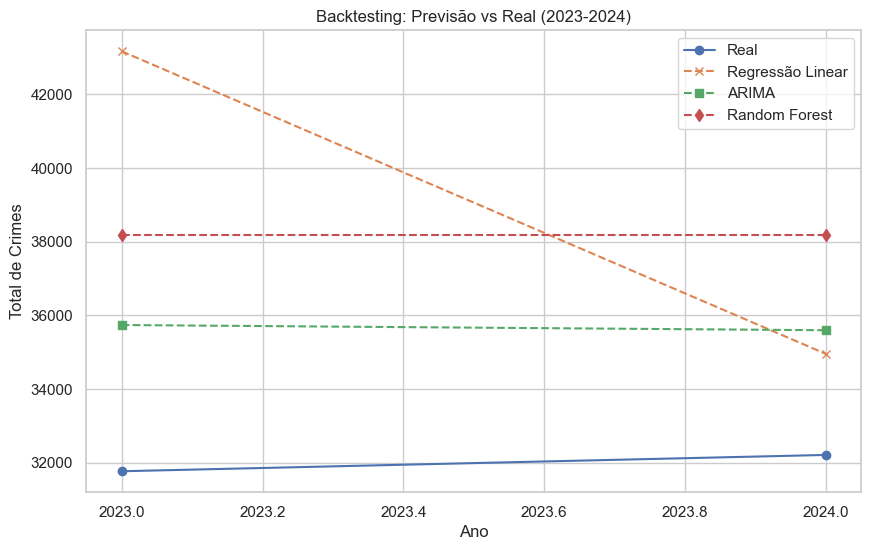

In [7]:
query_ano = '''
SELECT ano, SUM(registros) AS total_registros
FROM crimes
GROUP BY ano
ORDER BY ano
'''
df_ano = pd.read_sql_query(query_ano, conn_crimes)


train_df = df_ano[df_ano['ano'] <= 2022]
test_df = df_ano[(df_ano['ano'] > 2022) & (df_ano['ano'] <= 2024)]


def backtesting(train, test):
    X_train = train['ano'].values.reshape(-1,1)
    y_train = train['total_registros'].values
    X_test = test['ano'].values.reshape(-1,1)
    y_test = test['total_registros'].values

    
    model_lr = LinearRegression()
    model_lr.fit(X_train, y_train)
    pred_lr = model_lr.predict(X_test)

    
    serie_train = pd.Series(y_train, index=train['ano'])
    model_arima = ARIMA(serie_train, order=(1,1,1)).fit()
    pred_arima = model_arima.forecast(steps=len(test))

    
    model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
    model_rf.fit(X_train, y_train)
    pred_rf = model_rf.predict(X_test)

   
    resultados = {}

    for nome, pred in zip(['Regressão Linear', 'ARIMA', 'Random Forest'], [pred_lr, pred_arima, pred_rf]):
        mae = mean_absolute_error(y_test, pred)
        mse = mean_squared_error(y_test, pred)
        rmse = np.sqrt(mse)
        resultados[nome] = {'MAE': mae, 'RMSE': rmse}

    
    return resultados, y_test, pred_lr, pred_arima, pred_rf, test['ano'].values


resultados, y_test, pred_lr, pred_arima, pred_rf, anos_test = backtesting(train_df, test_df)


print("Resultados do Backtesting (2023-2024):")
for modelo, metricas in resultados.items():
    print(f"{modelo}: MAE = {metricas['MAE']:.2f}, RMSE = {metricas['RMSE']:.2f}")


plt.figure(figsize=(10,6))
plt.plot(anos_test, y_test, 'o-', label='Real')
plt.plot(anos_test, pred_lr, 'x--', label='Regressão Linear')
plt.plot(anos_test, pred_arima, 's--', label='ARIMA')
plt.plot(anos_test, pred_rf, 'd--', label='Random Forest')
plt.title('Backtesting: Previsão vs Real (2023-2024)')
plt.xlabel('Ano')
plt.ylabel('Total de Crimes')
plt.legend()
plt.grid(True)
plt.show()

# 📊 4. Modelagem e Previsão para 2025

Nesta seção, utilizamos os dados históricos consolidados de crimes violentos em Minas Gerais para realizar previsões do total de ocorrências em 2025.

A modelagem é baseada em técnicas de séries temporais, com foco no modelo **ARIMA (AutoRegressive Integrated Moving Average)**, conhecido por sua capacidade de capturar padrões e tendências temporais em dados históricos.

Além da previsão bruta, estimamos também o **índice de crimes ajustado por 100 mil habitantes**, utilizando projeções populacionais baseadas nos dados do IBGE. Isso permite uma análise mais justa da evolução dos crimes ao longo do tempo, considerando o crescimento populacional.

Por fim, são gerados gráficos comparativos e previsões com **intervalos de confiança**, que ajudam a interpretar a incerteza associada aos modelos.


### 4.1 Previsão ARIMA para total de crimes em MG em 2025:

Previsão ARIMA para total de crimes em MG em 2025: 32,396


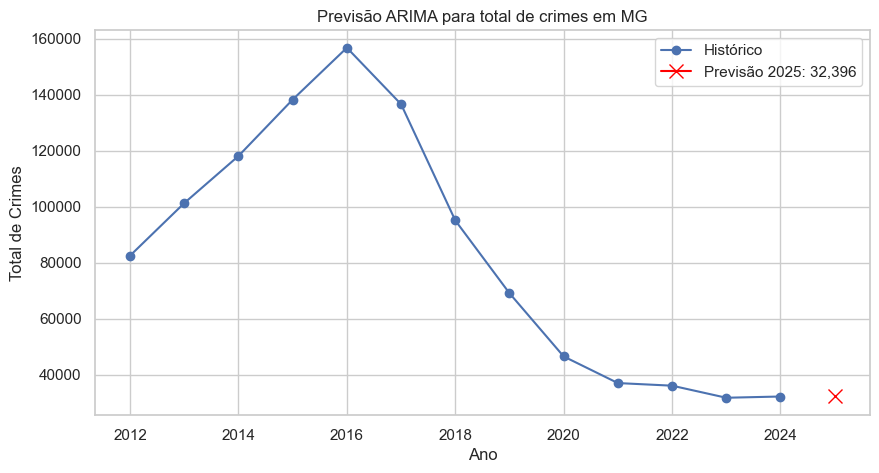

In [8]:
serie_completa = pd.Series(df_ano['total_registros'].values, index=df_ano['ano'])

modelo_arima = ARIMA(serie_completa, order=(1,1,1))
modelo_treinado = modelo_arima.fit()

previsao_2025 = modelo_treinado.forecast(steps=1).iloc[0]
print(f"Previsão ARIMA para total de crimes em MG em 2025: {int(previsao_2025):,}")

plt.figure(figsize=(10,5))
plt.plot(serie_completa, marker='o', label='Histórico')
plt.plot(2025, previsao_2025, marker='x', markersize=10, color='red', label=f'Previsão 2025: {int(previsao_2025):,}')
plt.title('Previsão ARIMA para total de crimes em MG')
plt.xlabel('Ano')
plt.ylabel('Total de Crimes')
plt.legend()
plt.grid(True)
plt.show()

### 4.2  Análise da População Estimada para 2025 e Cálculo de Crimes por 100 mil Habitantes

Nesta etapa, estimamos a população de Minas Gerais para o ano de 2025 com base na projeção a partir dos dados disponíveis em 2024, obtidos no repositório oficial do IBGE.

> ⚠️ **Aviso:** Como o último dado oficial disponível é referente ao ano de 2024, a estimativa populacional para 2025 foi calculada com base em taxas médias de crescimento observadas nos anos anteriores, utilizando um modelo simplificado de projeção. Por isso, os indicadores de "crimes por 100 mil habitantes" devem ser interpretados como **estimativas**, e não como valores exatos de referência oficial

In [10]:
query_pop_2024 = '''
SELECT SUM(populacaoestimada) as populacao_total_2024
FROM municipios
'''
df_pop_2024 = pd.read_sql_query(query_pop_2024, conn_ibge)
pop_2024 = float(df_pop_2024.loc[0, 'populacao_total_2024'])
print(f"População total estimada de MG em 2024: {int(pop_2024):,}")

crescimento_apos_2022 = 0.0381
pop_2025 = pop_2024 * (1 + crescimento_apos_2022)
print(f"População total estimada de MG em 2025: {int(pop_2025):,}")

crescimento_ate_2022 = 0.048
anos = list(range(2012, 2026))  # Inclui 2025
pop_ano = pop_2024

for ano in range(2024, 2011, -1):
    if ano > 2022:
        pop_ano /= (1 + crescimento_apos_2022)
    else:
        pop_ano /= (1 + crescimento_ate_2022)
pop_2012 = pop_ano

populacao_estimada = []
pop_atual = pop_2012
for ano in anos:
    populacao_estimada.append(pop_atual)
    if ano < 2022:
        pop_atual *= (1 + crescimento_ate_2022)
    else:
        pop_atual *= (1 + crescimento_apos_2022)

df_pop = pd.DataFrame({'ano': anos, 'populacao': populacao_estimada})

df_ajustado = pd.merge(df_ano[df_ano['ano'] <= 2024], df_pop, on='ano', how='left')
df_ajustado['crimes_por_100mil'] = df_ajustado['total_registros'] / df_ajustado['populacao'] * 100000

fig = px.line(df_ajustado, x='ano', y='crimes_por_100mil',
              title='Total de Crimes por 100 mil Habitantes em MG (2012–2024) com crescimento populacional ajustado',
              labels={'ano': 'Ano', 'crimes_por_100mil': 'Crimes por 100 mil habitantes'},
              markers=True)
fig.update_layout(yaxis_tickformat=',.0f')

# Anotar valores
for i, row in df_ajustado.iterrows():
    fig.add_annotation(x=row['ano'], y=row['crimes_por_100mil'],
                       text=f"{int(row['crimes_por_100mil']):,}",
                       showarrow=True,
                       arrowhead=1,
                       ax=0,
                       ay=-15,
                       font=dict(size=10, color="black"))

fig.show()


serie_crimes_100mil = pd.Series(df_ajustado['crimes_por_100mil'].values, index=df_ajustado['ano'])


modelo = ARIMA(serie_crimes_100mil, order=(1,1,1))
modelo_fit = modelo.fit()


forecast_res = modelo_fit.get_forecast(steps=1)
media_prevista = forecast_res.predicted_mean.values[0]
ic = forecast_res.conf_int(alpha=0.05)  # 95%
lower = ic.iloc[0, 0]
upper = ic.iloc[0, 1]

print(f"🔮 Previsão para 2025: {media_prevista:.2f}")
print(f"🔎 Intervalo de confiança 95%: ({lower:.2f}, {upper:.2f})")


df_prev_2025 = pd.DataFrame({'ano': [2025], 'crimes_por_100mil': [media_prevista]})
df_plot = pd.concat([df_ajustado[['ano', 'crimes_por_100mil']], df_prev_2025], ignore_index=True)


fig = go.Figure()


fig.add_trace(go.Scatter(x=df_ajustado['ano'], y=df_ajustado['crimes_por_100mil'],
                         mode='lines+markers', name='Histórico'))


fig.add_trace(go.Scatter(x=[2025], y=[media_prevista],
                         mode='markers+text',
                         marker=dict(size=10, color='red'),
                         text=["Previsão 2025"],
                         textposition="top center",
                         name='Previsão 2025'))


fig.add_trace(go.Scatter(
    x=[2025, 2025],
    y=[lower, upper],
    fill=None,
    mode='lines',
    line=dict(color='rgba(255,0,0,0.4)', dash='dot'),
    showlegend=True,
    name='IC 95%'
))


fig.update_layout(title='Previsão ARIMA: Crimes por 100 mil habitantes em MG (2012–2025)',
                  xaxis_title='Ano',
                  yaxis_title='Crimes por 100 mil habitantes',
                  yaxis_tickformat=',.2f',
                  template='plotly_white')

fig.show()

População total estimada de MG em 2024: 21,322,691
População total estimada de MG em 2025: 22,135,085


🔮 Previsão para 2025: 158.44
🔎 Intervalo de confiança 95%: (22.77, 294.11)


### 4.3 Ranking das 10 Naturezas de Crime com Maior Previsão para 2025
Esta seção apresenta uma análise preditiva das 10 naturezas de crimes com maior volume estimado para o ano de 2025 em Minas Gerais, com base na modelagem ARIMA aplicada às séries temporais de 2012 a 2024.

> ⚠️ **Aviso:** Os valores apresentados são resultados de modelos estatísticos aplicados aos dados históricos e **não representam previsões exatas**. Eles devem ser interpretados como **estimativas com base nas tendências observadas**, podendo variar conforme fatores externos não modelados (ex: políticas públicas, contextos sociais, etc.).

In [13]:
query = '''
SELECT ano, natureza, SUM(registros) AS total_crimes
FROM crimes
WHERE ano BETWEEN 2012 AND 2024
GROUP BY natureza, ano
ORDER BY natureza, ano
'''
df = pd.read_sql_query(query, conn_crimes)


previsoes = []

for natureza, grupo in df.groupby('natureza'):
    if grupo.shape[0] >= 6: 
        serie = pd.Series(grupo['total_crimes'].values, index=grupo['ano'].values)
        try:
            model = ARIMA(serie, order=(1,1,1)).fit()
            forecast = model.forecast(steps=1)
            previsoes.append({
                'natureza': natureza,
                'previsao_2025': forecast.iloc[0],
                'valor_2024': grupo[grupo['ano'] == 2024]['total_crimes'].values[0] if 2024 in grupo['ano'].values else np.nan
            })
        except:
            continue


df_prev = pd.DataFrame(previsoes)
df_prev.dropna(inplace=True)
df_prev['variacao_%'] = ((df_prev['previsao_2025'] - df_prev['valor_2024']) / df_prev['valor_2024']) * 100


df_top10 = df_prev.sort_values(by='previsao_2025', ascending=False).head(10).reset_index(drop=True)


df_top10['valor_2024'] = df_top10['valor_2024'].astype(int)
df_top10['previsao_2025'] = df_top10['previsao_2025'].astype(int)
df_top10['variacao_%'] = df_top10['variacao_%'].round(2)


df_top10.rename(columns={
    'natureza': 'Natureza',
    'valor_2024': 'Crimes 2024',
    'previsao_2025': 'Previsão 2025',
    'variacao_%': 'Variação (%)'
}, inplace=True)


print("\n Ranking das 10 naturezas de crime com maior previsão para 2025:\n")
print(df_top10.to_string(index=False))


 Ranking das 10 naturezas de crime com maior previsão para 2025:

                             Natureza  Previsão 2025  Crimes 2024  Variação (%)
                      Roubo Consumado          18647        18595          0.28
      Estupro de Vulneravel Consumado           3657         3600          1.59
                    Homicidio Tentado           3383         3009         12.44
        Homicidio Consumado Registros           2708         2635          2.81
                        Roubo Tentado           1437         1171         22.74
                    Estupro Consumado           1436         1309          9.71
                   Extorsao Consumado           1019         1019          0.00
Sequestro e Carcere Privado Consumado            307          297          3.42
                      Estupro Tentado            227          213          6.63
                     Extorsao Tentado            185          190         -2.43
